In [4]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#       STEP 3 - SPECTRA
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
from dynamics_tools import S_jonswap
from scipy.optimize import brentq

#==== LOAD FEM RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')

freq =fem['freq']
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])

elements=elem_w+elem_a
nodes=elements+1
z_nodes=np.array([i*le for i in range(nodes)])
z_above=z_nodes-Hw

f1=freq[0]
f2=freq[1]
T1=1/f1

print(f"Loaded FEM results")
print(f"f1={f1:.4f} Hz, T1={T1:.2f} s")
print(f"f2={f2:.4f} Hz")


Loaded FEM results
f1=0.1397 Hz, T1=7.16 s
f2=1.2122 Hz


In [5]:
# ====== LOAD CASES =======
g=9.81
F_fetch=180e3  # fetch [m]
z0=0.001       # roughness length, open sea [m]

# LC2 - reference wind speed given, derive wave period
U10_LC2 = 19.0
Tp_LC2= 0.286*(g*F_fetch/U10_LC2**2)**0.33*U10_LC2/g
Hs_LC2=0.0016*np.sqrt(g*F_fetch/U10_LC2**2)*U10_LC2**2/g

# LC1 - Wave peak period equals first natural period, derive wind speed
Tp_LC1=T1
U10_LC1=brentq(
    lambda U: 0.286*(g*F_fetch/U**2)**0.33*U/g-Tp_LC1, 
    1.0, 50.0
)
Hs_LC1=0.0016*np.sqrt(g*F_fetch/U10_LC1**2)*U10_LC1**2/g

print(f"\nLoad Cases")
print(f"LC1: U10= {U10_LC1:.2f} m/s, Tp= {Tp_LC1:.2f} s, Hs= {Hs_LC1:.2f}")
print(f"LC2: U10= {U10_LC2:.2f} m/s, Tp= {Tp_LC2:.2f} s, Hs= {Hs_LC2:.2f}")




Load Cases
LC1: U10= 9.26 m/s, Tp= 7.16 s, Hs= 2.01
LC2: U10= 19.00 m/s, Tp= 9.14 s, Hs= 4.12


In [6]:
# ===== MEAN WIND PROFILE =====
z0=0.001 # roughness length, open sea [m]

def mean_wind(U10, z, z0):
    z_pos=np.maximum(z, z0)
    return U10*np.log(z_pos/z0)/np.log(10.0/z0)

# only valid above waterline

U_mean_LC1=np.where(z_above > 0, mean_wind(U10_LC1, z_above, z0), 0.0)
U_mean_LC2=np.where(z_above > 0, mean_wind(U10_LC2, z_above, z0), 0.0)

print(f"\n Mean Wind Profile")
print(f"LC1 tip wind speed: {U_mean_LC1[-1]:.2f} m/s")
print(f"LC2 tip wind speed: {U_mean_LC2[-1]:.2f} m/s")




 Mean Wind Profile
LC1 tip wind speed: 11.66 m/s
LC2 tip wind speed: 23.91 m/s


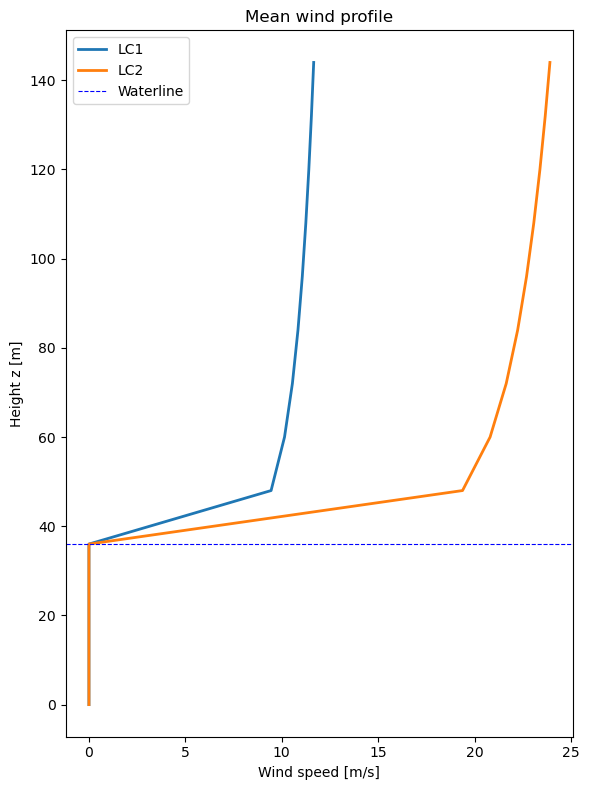

In [7]:
#plot
fig, ax=plt.subplots(figsize=(6, 8))
ax.plot(U_mean_LC1, z_nodes, linewidth=2, label='LC1')
ax.plot(U_mean_LC2, z_nodes, linewidth=2, label='LC2')
ax.axhline(Hw, color='blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Height z [m]')
ax.set_title('Mean wind profile')
plt.tight_layout()
plt.legend()
plt.show()



In [8]:
# ===== KAIMAL SPECTRUM ====
N_freq=1000
f_max=2*f2                   # twice second natural frequency [Hz]
f_axis=np.linspace(0.01, f_max, N_freq) # [Hz], avoid f=0

I_u=0.06                     # turbulence intensity, offshore [-]
L_u=180                      # turbulence length scale [m]

def kaimal(f, U, I_u, L_u):
    sigma_u=I_u*U            # turbulence std dev [m/s]
    return 4*sigma_u**2*(L_u/U)/(1+6*f*L_u/U)**(5/3)

# compute at each air node for both load cases
# shape: (n_air_nodes, N_freq)
air_nodes= np.where(z_above > 0)[0]

S_kaimal_LC1=np.zeros((len(air_nodes), N_freq))
S_kaimal_LC2=np.zeros((len(air_nodes), N_freq))

for i, node in enumerate(air_nodes):
    S_kaimal_LC1[i, :]=kaimal(f_axis, U_mean_LC1[node], I_u, L_u)
    S_kaimal_LC2[i, :]=kaimal(f_axis, U_mean_LC2[node], I_u, L_u)

print(f"\ Kaimal Spectrum")
print(f"Frequency range: {f_axis[0]:.3f}-{f_axis[-1]:.3f} Hz")
print(f"Number of air nodes: {len(air_nodes)}")



\ Kaimal Spectrum
Frequency range: 0.010-2.424 Hz
Number of air nodes: 9


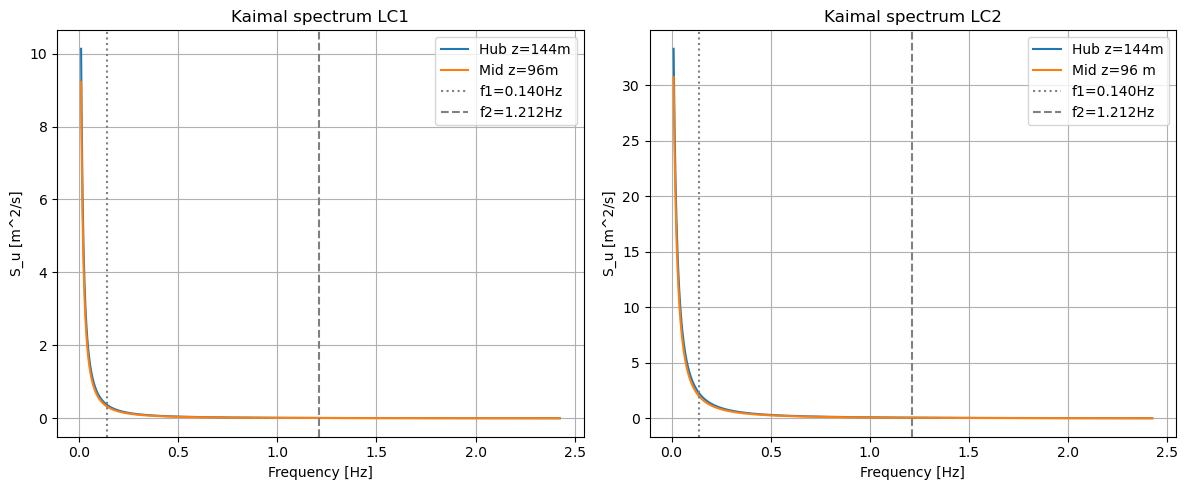

In [9]:
# plot at hub height (top node) and mid-height for both load cases
fig, axes= plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(f_axis, S_kaimal_LC1[-1,:], label=f'Hub z={z_nodes[air_nodes[-1]]:.0f}m')
axes[0].plot(f_axis, S_kaimal_LC1[len(air_nodes)//2, :],
             label=f"Mid z={z_nodes[air_nodes[len(air_nodes)//2]]:.0f}m")
axes[0].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f}Hz')
axes[0].axvline(f2, color='gray', linestyle='--', label=f'f2={f2:.3f}Hz')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('S_u [m^2/s]')
axes[0].set_title('Kaimal spectrum LC1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f_axis, S_kaimal_LC2[-1, :], label=f'Hub z={z_nodes[air_nodes[-1]]:.0f}m')
axes[1].plot(f_axis, S_kaimal_LC2[len(air_nodes)//2, :],
             label=f'Mid z={z_nodes[air_nodes[len(air_nodes)//2]]:.0f} m')
axes[1].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f}Hz')
axes[1].axvline(f2, color='gray', linestyle='--', label=f'f2={f2:.3f}Hz')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('S_u [m^2/s]')
axes[1].set_title('Kaimal spectrum LC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [10]:
# ===== JONSWAP SPECTRUM ======
gamma=3.3 #peak enhancement factor

# Because of error in step 4:

omega_p_LC1=2*np.pi/Tp_LC1
omega_p_LC2=2*np.pi/Tp_LC2

omega_axis=2*np.pi*f_axis # convert Hz to rad/s

print(f"omega_axis range: {omega_axis[0]:.3f} to {omega_axis[-1]:.3f} rad/s")
print(f"omega_p LC1: {omega_p_LC1:.3f} rad/s")
print(f"omega_p LC2: {omega_p_LC2:.3f} rad/s")



omega_axis range: 0.063 to 15.232 rad/s
omega_p LC1: 0.878 rad/s
omega_p LC2: 0.687 rad/s


In [11]:
def compute_alpha(Hs_target, omega_axis, omega_p, gamma):
    alpha_try=0.0081
    for _ in range(100):
        S_try=S_jonswap(alpha_try, omega_axis, omega_p, gamma)
        domega=omega_axis[1]-omega_axis[0]
        Hs_try=4*np.sqrt(np.sum(S_try*domega))
        alpha_try*=(Hs_target/Hs_try)**2
    return alpha_try

alpha_LC1=compute_alpha(Hs_LC1, omega_axis, omega_p_LC1, gamma)
alpha_LC2=compute_alpha(Hs_LC2, omega_axis, omega_p_LC2, gamma)

print(f"alpha LC1: {alpha_LC1:.6f}")
print(f"alpha LC2: {alpha_LC2:.6f}")



alpha LC1: 0.005091
alpha LC2: 0.008062


In [12]:
S_jonswap_LC1=S_jonswap(alpha_LC1, omega_axis, omega_p_LC1, gamma)
S_jonswap_LC2=S_jonswap(alpha_LC2, omega_axis, omega_p_LC2, gamma)

print(f"\n JONSWAP Spectrum")
print(f"LC1: omega_p={omega_p_LC1:.4f} rad/s, Tp= {Tp_LC1:.2f}s")
print(f"LC2: omega_p={omega_p_LC2:.4f} rad/s, Tp= {Tp_LC2:.2f}s")




 JONSWAP Spectrum
LC1: omega_p=0.8776 rad/s, Tp= 7.16s
LC2: omega_p=0.6874 rad/s, Tp= 9.14s


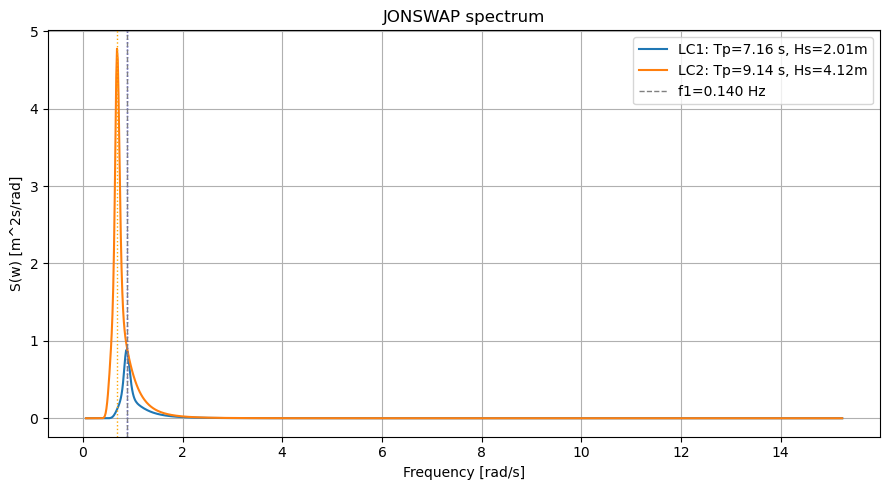

In [13]:
fig, ax= plt.subplots(figsize=(9,5))
ax.plot(omega_axis, S_jonswap_LC1, label=f'LC1: Tp={Tp_LC1:.2f} s, Hs={Hs_LC1:.2f}m')
ax.plot(omega_axis, S_jonswap_LC2, label=f'LC2: Tp={Tp_LC2:.2f} s, Hs={Hs_LC2:.2f}m')
ax.axvline(omega_p_LC1, color='blue', linestyle=':', linewidth=1)
ax.axvline(omega_p_LC2, color='orange', linestyle=':', linewidth=1)
ax.axvline(2*np.pi*f1, color='gray', linestyle='--', linewidth=1, label=f'f1={f1:.3f} Hz')
ax.set_xlabel('Frequency [rad/s]')
ax.set_ylabel('S(w) [m^2s/rad]')
ax.set_title('JONSWAP spectrum')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



In [14]:
# ===== CO-SPECTRA =====
# Coherence decay coefficient (IEC standard)
a_coh =12.0

def coherence(f, zi, zj, U_mean_i, U_mean_j, a_coh):
    U_avg=0.5*(U_mean_i+U_mean_j)
    dz=abs(zi-zj)
    return np.exp(-a_coh*f*dz/U_avg)

# co-spectrum between nodes i and j
def co_spectrum(f, zi, zj, U_i, U_j, I_u, L_u, a_coh):
    Si=kaimal(f, U_i, I_u, L_u)
    Sj=kaimal(f, U_j, I_u, L_u)
    coh=coherence(f, zi, zj, U_i, U_j, a_coh)
    return np.sqrt(Si*Sj)*coh

# build co-spectrum matrix at each frequency
# shape: (n_air_nodes, n_air_nodes, N_freq)
n_air=len(air_nodes)
S_co_LC1=np.zeros((n_air, n_air, N_freq))
S_co_LC2=np.zeros((n_air, n_air, N_freq))

for i in range(n_air):
    for j in range(n_air):
        zi=z_above[air_nodes[i]]
        zj=z_above[air_nodes[j]]
        U_i_LC1=U_mean_LC1[air_nodes[i]]
        U_j_LC1=U_mean_LC1[air_nodes[j]]
        U_i_LC2=U_mean_LC2[air_nodes[i]]
        U_j_LC2=U_mean_LC2[air_nodes[j]]
        S_co_LC1[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC1, U_j_LC1, I_u, L_u, a_coh)
        S_co_LC2[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC2, U_j_LC2, I_u, L_u, a_coh)

print(f"\n Co-spectra")
print(f"Co-spectrum matrix shape: {S_co_LC1.shape}")
print(f"Diagonal check (should equal auto-spectrum at node 0):")
print(f"S_co[0,0] at f=0.14 Hz: {S_co_LC1[0,0,np.argmin(abs(f_axis-0.14))]:.4f}")
print(f" S_kaimal[0] at f=0.14 Hz: {S_kaimal_LC1[0,np.argmin(abs(f_axis-0.14))]:.4f}")




 Co-spectra
Co-spectrum matrix shape: (9, 9, 1000)
Diagonal check (should equal auto-spectrum at node 0):
S_co[0,0] at f=0.14 Hz: 0.2165
 S_kaimal[0] at f=0.14 Hz: 0.2165


In [15]:
domega_check=omega_axis[1]-omega_axis[0]
print(f"Hs check before save LC1: {4*np.sqrt(np.sum(S_jonswap_LC1*domega_check)):.3f} m")
print(f"Hs check before save LC2: {4*np.sqrt(np.sum(S_jonswap_LC2*domega_check)):.3f} m")


Hs check before save LC1: 2.008 m
Hs check before save LC2: 4.118 m


In [16]:
#==== SAVE OUTPUTS ======
output_dir = NOTEBOOK_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

np.savez(output_dir / 'spectra_results.npz',
    #load case parameters
    U10_LC1=np.array([U10_LC1]),
    U10_LC2=np.array([U10_LC2]),
    Tp_LC1=np.array([Tp_LC1]),
    Tp_LC2=np.array([Tp_LC2]),
    Hs_LC1=np.array([Hs_LC1]),
    Hs_LC2=np.array([Hs_LC2]),
    #frequency axis
    f_axis=f_axis,
    omega_axis=omega_axis,
    # wind profiles
    U_mean_LC1=U_mean_LC1,
    U_mean_LC2=U_mean_LC2,
    z_nodes=z_nodes,
    z_above=z_above,
    air_nodes=air_nodes,
    # Kaimal spectra
    S_kaimal_LC1=S_kaimal_LC1,
    S_kaimal_LC2=S_kaimal_LC2,
    #co-spectra
    S_co_LC1=S_co_LC1,
    S_co_LC2=S_co_LC2,
    #JONSWAP
    S_jonswap_LC1=S_jonswap_LC1,
    S_jonswap_LC2=S_jonswap_LC2,
    omega_p_LC1=np.array([omega_p_LC1]),
    omega_p_LC2=np.array([omega_p_LC2])
)
print("\nSpectra results saved to outputs/spectra_results.npz")


Spectra results saved to outputs/spectra_results.npz
